In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("movie.csv")

In [4]:
df.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


In [5]:
df.size

80000

In [6]:
df.info

<bound method DataFrame.info of                                                     text  label
0      I grew up (b. 1965) watching and loving the Th...      0
1      When I put this movie in my DVD player, and sa...      0
2      Why do people who do not know what a particula...      0
3      Even though I have great interest in Biblical ...      0
4      Im a die hard Dads Army fan and nothing will e...      1
...                                                  ...    ...
39995  "Western Union" is something of a forgotten cl...      1
39996  This movie is an incredible piece of work. It ...      1
39997  My wife and I watched this movie because we pl...      0
39998  When I first watched Flatliners, I was amazed....      1
39999  Why would this film be so good, but only gross...      1

[40000 rows x 2 columns]>

In [ ]:
df['label'].value_counts() #This step checks the snetiment distribution in dataset.
                           #As the dataset is almost perfectly balanced, it reduces the risk of model becoming biased towards one class
                           

label
0    20019
1    19981
Name: count, dtype: int64

<Axes: xlabel='label'>

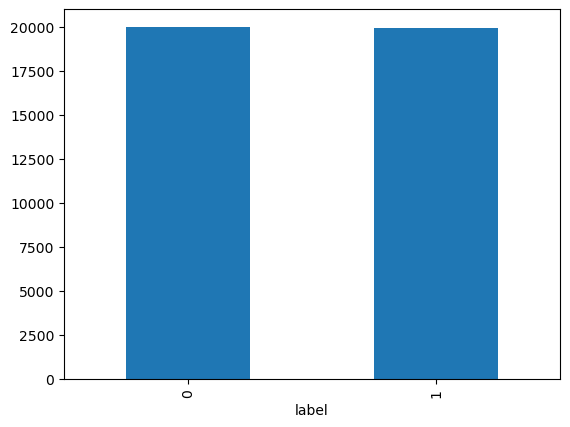

In [8]:
df['label'].value_counts().plot(kind="bar")

In [9]:
df.sample(5)

,text,label
22849,"Are sea side resorts the sad, dreary places th...",1
11842,What can I say? This was hands-down the worst ...,0
39233,YETI deserves the 8 star rating because it is ...,1
11804,"This film is, quite simply, brilliant. The cin...",1
31337,It has its merit's; Morvern Callar is both the...,0


In [ ]:
df['review_length'] = df['text'].apply(len)

df['review_length'].describe()

# Descriptive statistical analysis of review lengths:

# 1. The dataset contains 40,000 reviews, and the count confirms there are no missing values.

# 2. The mean review length (1310) is greater than the median (973), suggesting a
#   right-skewed distribution where a small number of very long reviews increase the average.

# 3. The minimum review length is 32 characters, showing that some reviews are very short,
#    which may provide limited information for sentiment classification.

# 4. The maximum review length (13704 characters) is significantly larger than the
#    majority of reviews, indicating the presence of extreme outliers. Very long
#    reviews may contain mixed sentiments or additional contextual information
#    (plot summaries, comparisons, etc.), which can introduce noise and make
#    sentiment classification more challenging.


count    40000.000000
mean      1310.293250
std        988.358599
min         32.000000
25%        698.000000
50%        973.000000
75%       1596.000000
max      13704.000000
Name: review_length, dtype: float64

(0.0, 7000.0)

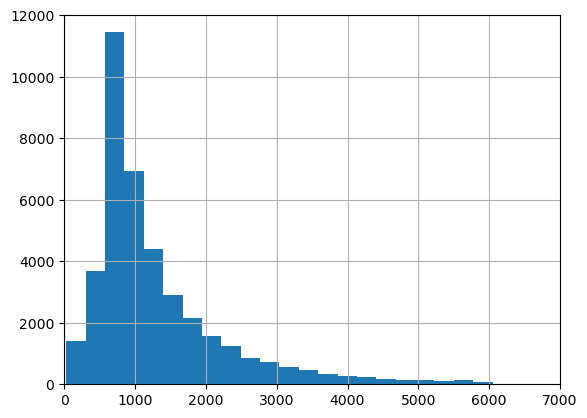

In [11]:
df['review_length'].hist(bins=50)
plt.xlim(0, 7000)

<Axes: >

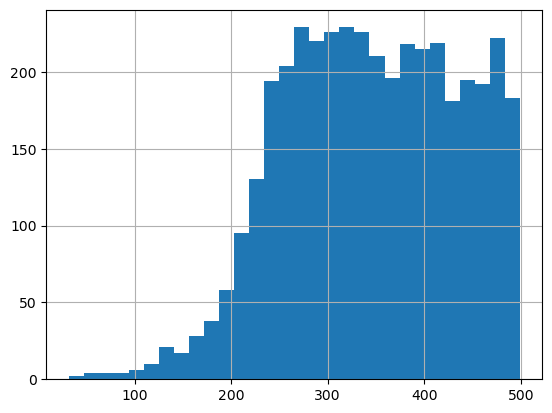

In [12]:
df[df['review_length'] < 500]['review_length'].hist(bins=30)

In [13]:
df

,text,label,review_length
0,I grew up (b. 1965) watching and loving the Th...,0,874
1,"When I put this movie in my DVD player, and sa...",0,1811
2,Why do people who do not know what a particula...,0,983
3,Even though I have great interest in Biblical ...,0,351
4,Im a die hard Dads Army fan and nothing will e...,1,983
...,...,...,...
39995,"""Western Union"" is something of a forgotten cl...",1,3111
39996,This movie is an incredible piece of work. It ...,1,291
39997,My wife and I watched this movie because we pl...,0,1092
39998,"When I first watched Flatliners, I was amazed....",1,1045


In [ ]:
df.isnull().sum()
# Counting the total number of NUll values
# NO null values. SO,filling required

text             0
label            0
review_length    0
dtype: int64

In [15]:
df['text'].sample(5).tolist()

["This movie is a masterpiece of brilliant acting and timely patriotic sense of pride in America. The Nazi Saboteurs of the 40's are replaced by the Middle East Terrorists of today. The intent is the same, to terrorize, disrupt lives, destroy property, and kill Americans! We see a wrongly accused Barry (Bob Cummings) on the lamm, trying to uncover the real Nazi terrorists plot, meeting the beautiful Pat (Priscilla Lane) and together, they travel to New York chasing the devious and evil saboteur Fry, played expertly by Norman Lloyd. Along the way, they encounter the also very sinister Otto Kruger playing the leader of the Nazi saboteur ring but disguised as a distinguished model citizen, where Barry seeking saboteur Fry, takes him into his confidence, only to handed over to the local law enforcement. He escapes, meets a kindly blind gentleman and his niece, enter Priscilla Lane. From there, Barry and Pat travel to Soda City Cal., run into the West coast saboteur gang heading East. They 

In [ ]:
df['text'].str.contains("<br").sum()
# Counting the number of HTML tags
# There are 23363 HTML tags which are noise for the model training which needs to be removed 

np.int64(23363)

In [17]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['word_count'].describe()


count    40000.000000
mean       231.339250
std        171.194123
min          4.000000
25%        126.000000
50%        173.000000
75%        282.000000
max       2470.000000
Name: word_count, dtype: float64

In [ ]:
# Data cleaning 
\
# The goal of data cleaning is reducing noise and making patterns easier for the model to learn. 
import re

def clean_text(text):

    # lowercase
    text = text.lower() # Turning review in lower text becuase it shoudn't treat same word differently Ex: AMAZING and amazing

    # remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # remove non alphabet characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [19]:
df['clean_review'] = df['text'].apply(clean_text)

In [20]:
df

,text,label,review_length,word_count,clean_review
0,I grew up (b. 1965) watching and loving the Th...,0,874,151,i grew up b watching and loving the thunderbir...
1,"When I put this movie in my DVD player, and sa...",0,1811,326,when i put this movie in my dvd player and sat...
2,Why do people who do not know what a particula...,0,983,184,why do people who do not know what a particula...
3,Even though I have great interest in Biblical ...,0,351,69,even though i have great interest in biblical ...
4,Im a die hard Dads Army fan and nothing will e...,1,983,178,im a die hard dads army fan and nothing will e...
...,...,...,...,...,...
39995,"""Western Union"" is something of a forgotten cl...",1,3111,541,western union is something of a forgotten clas...
39996,This movie is an incredible piece of work. It ...,1,291,50,this movie is an incredible piece of work it e...
39997,My wife and I watched this movie because we pl...,0,1092,168,my wife and i watched this movie because we pl...
39998,"When I first watched Flatliners, I was amazed....",1,1045,168,when i first watched flatliners i was amazed i...


In [21]:
df[["clean_review","label","review_length","word_count"]].to_csv("imdb_cleaned.csv", index=False)